# 05 - Analyse des pays

## Objectif

Cette analyse étudie la répartition géographique des contenus du catalogue.

La colonne `country` peut contenir plusieurs pays pour un même contenu. Nous allons donc séparer ces valeurs afin d'obtenir une analyse plus précise.


## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## 2. Chargement des données

In [2]:
df = pd.read_csv("../data/processed/netflix_titles_clean.csv")

print(f"Nombre de contenus : {len(df)}")


Nombre de contenus : 8807


## 3. Exploration de la colonne `country`

In [3]:
df["country"].head(15)


0                                         United States
1                                          South Africa
2                                               Unknown
3                                               Unknown
4                                                 India
5                                               Unknown
6                                               Unknown
7     United States, Ghana, Burkina Faso, United Kin...
8                                        United Kingdom
9                                         United States
10                                              Unknown
11                                              Unknown
12                              Germany, Czech Republic
13                                              Unknown
14                                              Unknown
Name: country, dtype: str

## 4. Séparation des pays

In [4]:
countries = (
    df["country"]
    .str.split(", ")
    .explode()
)

country_counts = countries.value_counts()

country_counts.head(20)


country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Hong Kong          105
Nigeria            103
Italy              100
Brazil              97
Argentina           91
Name: count, dtype: int64

## 5. Nombre de pays représentés

In [5]:
print(f"Nombre de pays différents : {country_counts.shape[0]}")


Nombre de pays différents : 128


## 6. Top 15 des pays

In [6]:
top_countries = country_counts.head(15)

top_countries


country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Name: count, dtype: int64

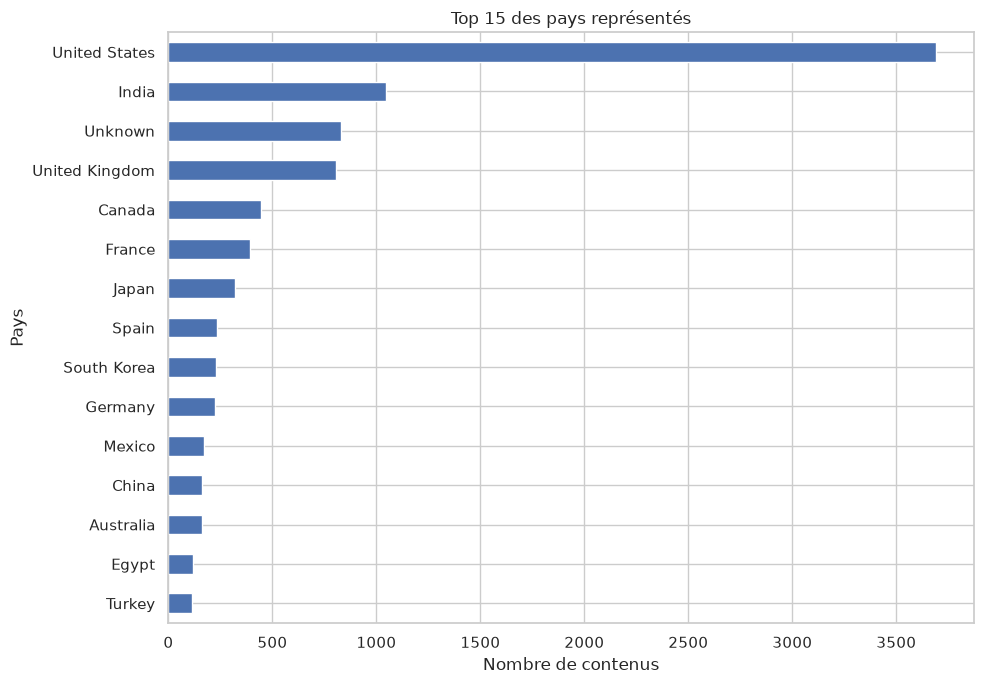

In [7]:
plt.figure(figsize=(10, 7))

top_countries.sort_values().plot(kind="barh")

plt.title("Top 15 des pays représentés")
plt.xlabel("Nombre de contenus")
plt.ylabel("Pays")
plt.tight_layout()
plt.show()


## 7. Films et séries par pays

In [8]:
df_countries = df.assign(
    country=df["country"].str.split(", ")
).explode("country")

country_by_type = (
    df_countries
    .groupby(["country", "type"])
    .size()
    .unstack(fill_value=0)
)

country_by_type["Total"] = country_by_type.sum(axis=1)

country_by_type.sort_values("Total", ascending=False).head(15)


type,Movie,TV Show,Total
country,,,
United States,2751,938,3689
India,962,84,1046
Unknown,440,391,831
United Kingdom,532,272,804
Canada,319,126,445
France,303,90,393
Japan,119,199,318
Spain,171,61,232
South Korea,61,170,231


## 8. Principaux pays producteurs de films

In [9]:
movie_countries = (
    df_countries[df_countries["type"] == "Movie"]["country"]
    .value_counts()
)

movie_countries.head(15)


country
United States     2751
India              962
United Kingdom     532
Unknown            440
Canada             319
France             303
Germany            182
Spain              171
Japan              119
China              114
Mexico             111
Egypt              102
Hong Kong          100
Nigeria             94
Australia           94
Name: count, dtype: int64

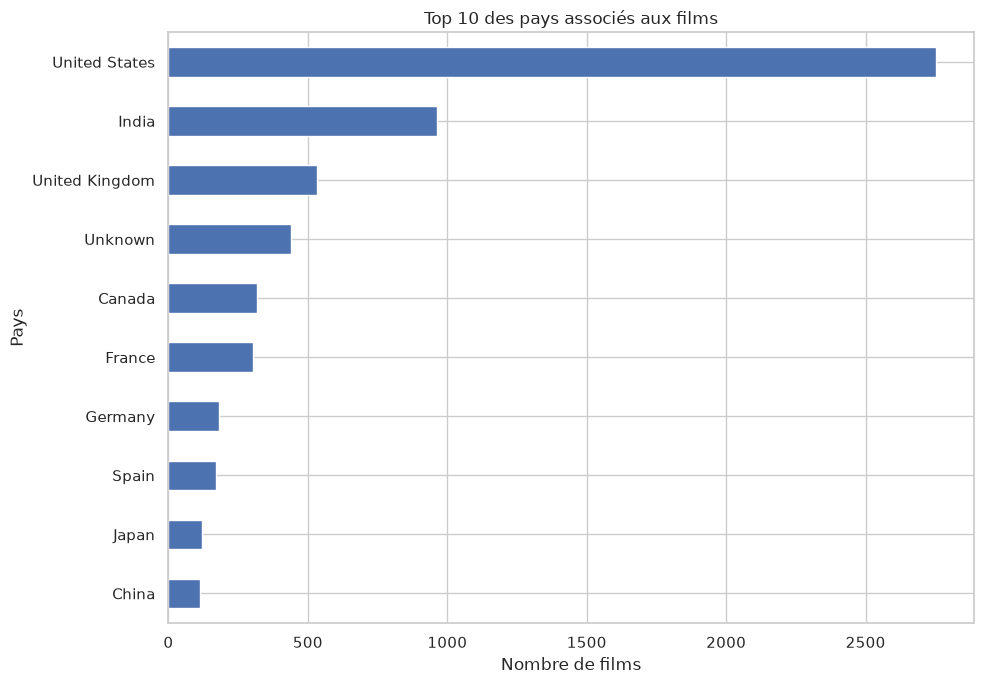

In [10]:
plt.figure(figsize=(10, 7))

movie_countries.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 des pays associés aux films")
plt.xlabel("Nombre de films")
plt.ylabel("Pays")
plt.tight_layout()
plt.show()


## 9. Principaux pays producteurs de séries

In [11]:
show_countries = (
    df_countries[df_countries["type"] == "TV Show"]["country"]
    .value_counts()
)

show_countries.head(15)


country
United States     938
Unknown           391
United Kingdom    272
Japan             199
South Korea       170
Canada            126
France             90
India              84
Taiwan             70
Australia          66
Spain              61
Mexico             58
China              48
Germany            44
Colombia           32
Name: count, dtype: int64

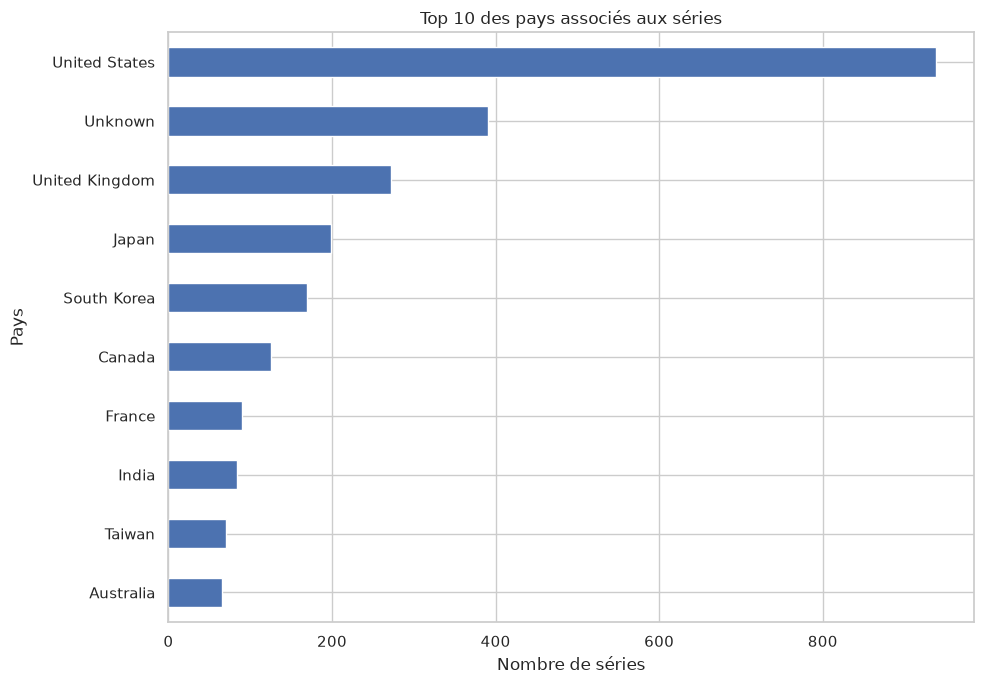

In [12]:
plt.figure(figsize=(10, 7))

show_countries.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 des pays associés aux séries")
plt.xlabel("Nombre de séries")
plt.ylabel("Pays")
plt.tight_layout()
plt.show()


## 10. Contenus associés à plusieurs pays

In [13]:
countries_per_content = (
    df["country"]
    .str.split(", ")
    .str.len()
)

print(
    f"Nombre moyen de pays associés à un contenu : "
    f"{countries_per_content.mean():.2f}"
)

print(
    f"Nombre maximum de pays associés à un contenu : "
    f"{countries_per_content.max()}"
)


Nombre moyen de pays associés à un contenu : 1.23
Nombre maximum de pays associés à un contenu : 12


## 11. Contenus internationaux

In [14]:
international_content = df[
    df["country"].str.contains(",", na=False)
]

print(
    f"Contenus associés à plusieurs pays : "
    f"{len(international_content)}"
)

print(
    f"Pourcentage du catalogue : "
    f"{len(international_content) / len(df) * 100:.2f}%"
)


Contenus associés à plusieurs pays : 1320
Pourcentage du catalogue : 14.99%


## 12. Observation

La colonne `country` ne représente pas nécessairement un unique pays de production.

Un même contenu peut être associé à plusieurs pays. Le nombre de contenus par pays correspond donc au nombre de contenus dans lesquels le pays apparaît, et non nécessairement au nombre de productions exclusivement réalisées dans ce pays.


## 13. Conclusion

L'analyse géographique permet d'identifier les pays les plus représentés dans le catalogue et de comparer leur présence dans les films et les séries.

La séparation des pays associés à plusieurs contenus permet également de mieux comprendre la dimension internationale du catalogue.
